<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 2: Clustering por Gaussian Mixture Models</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> En esta actividad construiras un clustering basado en GMM. 
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales: leea y responda los siguientes incisos</b>
<ul>
</ul>
</div>

**1.** Utilice GMM para la segmentación de clientes en el análisis de la cesta de la compra del siguiente dataset `customer_shopping.csv`. Emplee GMM para agrupar a los clientes según su comportamiento de compra. Una vez agrupados, podrá crear promociones dirigidas y recomendaciones personalizadas para cada segmento.

In [57]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [58]:
#Cargamos el dataset
df = pd.read_csv("C:/Users/x/OneDrive - MBGE INTERSISTEMAS/MBGE/DIT/IA/Maestria/Aprendizaje_Automatico_Avanzado_2026/Introducción/data/customer_shopping.csv")
df.head()

,Customer,Bread,Milk,Eggs,Beer,Chips
0,c001,12,10,8,0,1
1,c002,10,8,7,1,0
2,c003,11,9,6,0,1
3,c004,1,2,1,10,8
4,c005,0,1,2,12,10


In [59]:
df.isnull().sum()

Customer    0
Bread       0
Milk        0
Eggs        0
Beer        0
Chips       0
dtype: int64

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Customer  84 non-null     object
 1   Bread     84 non-null     int64 
 2   Milk      84 non-null     int64 
 3   Eggs      84 non-null     int64 
 4   Beer      84 non-null     int64 
 5   Chips     84 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 4.1+ KB


In [61]:
df.set_index('Customer', inplace=True)
df.head()

,Bread,Milk,Eggs,Beer,Chips
Customer,,,,,
c001,12,10,8,0,1
c002,10,8,7,1,0
c003,11,9,6,0,1
c004,1,2,1,10,8
c005,0,1,2,12,10


In [62]:
df.describe()

,Bread,Milk,Eggs,Beer,Chips
count,84.000000,84.000000,84.000000,84.000000,84.000000
mean,6.297619,5.297619,4.142857,5.333333,4.630952
std,4.976523,3.731274,3.089597,4.616193,3.892470
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,1.000000,1.000000
50%,5.000000,5.000000,4.000000,4.000000,4.000000
75%,11.000000,9.000000,7.000000,10.000000,8.000000
max,15.000000,12.000000,10.000000,14.000000,12.000000


In [63]:
# Escalamiento y selección de características, utilice las columnas 'Bread', 'Milk', 'Eggs', 'Beer', 'Chips'
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()
df_scale = pd.DataFrame(scale.fit_transform(df), columns=df.columns)
df_scale

,Bread,Milk,Eggs,Beer,Chips
0,1.152739,1.267831,1.255927,-1.162292,-0.938417
1,0.748438,0.728601,0.930316,-0.944363,-1.196866
2,0.950588,0.998216,0.604706,-1.162292,-0.938417
3,-1.070916,-0.889086,-1.023348,1.017006,0.870728
4,-1.273066,-1.158701,-0.697737,1.452865,1.387627
...,...,...,...,...,...
79,1.759190,1.537445,1.255927,-0.944363,-0.938417
80,-1.070916,-1.428316,-1.023348,0.799076,0.353829
81,-0.262314,-0.349857,-0.697737,-0.290573,-0.421519
82,1.152739,1.267831,0.604706,-0.944363,-0.938417


In [64]:
# Obtenemos valores de X
X = df[['Bread', 'Milk', 'Eggs', 'Beer', 'Chips']]
X.values

array([[12, 10,  8,  0,  1],
       [10,  8,  7,  1,  0],
       [11,  9,  6,  0,  1],
       [ 1,  2,  1, 10,  8],
       [ 0,  1,  2, 12, 10],
       [ 2,  1,  0,  9,  7],
       [ 6,  5,  4,  4,  3],
       [ 5,  6,  5,  5,  4],
       [14, 11,  9,  1,  0],
       [ 2,  0,  2, 11,  7],
       [11,  8,  7,  2,  0],
       [ 5,  7,  4,  4,  4],
       [12, 12,  8,  0,  1],
       [ 1,  3,  1, 13, 11],
       [ 9, 10,  7,  0,  2],
       [ 3,  0,  0, 14,  8],
       [15,  7,  5,  1,  1],
       [ 6,  4,  2,  6,  3],
       [10,  9,  9,  0,  0],
       [ 1,  1,  1, 10,  7],
       [13, 10,  6,  2,  2],
       [ 4,  6,  3,  5,  5],
       [ 1,  1,  2, 12,  9],
       [11,  8, 10,  2,  1],
       [ 1,  3,  2, 10, 11],
       [ 5,  4,  5,  3,  5],
       [ 0,  1,  0, 14,  8],
       [12, 11,  6,  1,  2],
       [ 2,  2,  2, 13,  6],
       [ 4,  3,  6,  3,  4],
       [11, 12,  6,  1,  0],
       [15,  9,  6,  1,  1],
       [ 0,  0,  2, 14,  9],
       [ 6,  7,  4,  4,  5],
       [ 3,  2

In [65]:
from sklearn.mixture import GaussianMixture

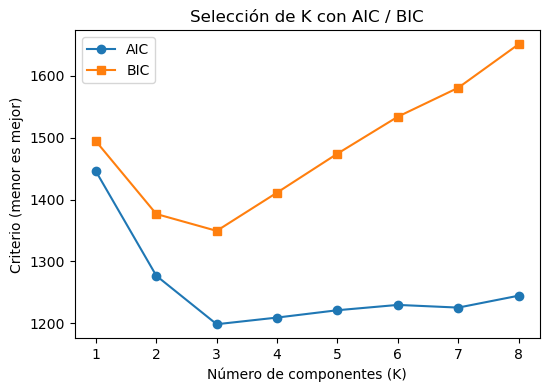

In [66]:
# Entrenar el modelo por GMM utilizando métricas para saber cuantos componentes elegir.
ks = range(1, 9)
aics, bics = [], []
for k in ks:
    g = GaussianMixture(n_components=k, covariance_type='full', random_state=42).fit(X)
    aics.append(g.aic(X))
    bics.append(g.bic(X))

plt.figure(figsize=(6, 4))
plt.plot(ks, aics, 'o-', label='AIC')
plt.plot(ks, bics, 's-', label='BIC')
plt.xlabel('Número de componentes (K)')
plt.ylabel('Criterio (menor es mejor)')
plt.title('Selección de K con AIC / BIC')
plt.legend()
plt.show()

In [67]:
# Entrene el modelo por GMM utilizando el K elegido con las métricas anteriores

gmm_shopping = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm_shopping.fit(X)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [68]:

# asignación dura (cluster más probable)
predicciones = gmm_shopping.predict(X)

# asignación suave (probabilidades de pertenencia)
responsabilidades = gmm_shopping.predict_proba(X)

print(f"Modelo entrenado con K = 3 componentes")
#print(f"Convergió: {gmm.converged_} en {gmm.n_iter_} iteraciones")


Modelo entrenado con K = 3 componentes


In [69]:
responsabilidades

array([[1.00000000e+000, 7.93852253e-073, 2.37676074e-023],
       [1.00000000e+000, 3.04125433e-050, 8.52048010e-014],
       [1.00000000e+000, 7.53851579e-053, 4.71254437e-017],
       [2.25752776e-115, 1.00000000e+000, 3.58784933e-021],
       [6.89364167e-160, 1.00000000e+000, 8.32209843e-037],
       [2.38151927e-097, 1.00000000e+000, 9.62753754e-016],
       [3.82988731e-019, 1.85060090e-015, 1.00000000e+000],
       [1.58554949e-026, 1.51906572e-016, 1.00000000e+000],
       [1.00000000e+000, 5.63275815e-095, 8.07686953e-032],
       [2.03216173e-113, 1.00000000e+000, 2.17614062e-021],
       [1.00000000e+000, 3.75320601e-054, 5.16793242e-014],
       [7.79260924e-023, 9.21359935e-017, 1.00000000e+000],
       [1.00000000e+000, 5.41852062e-080, 9.71327790e-026],
       [8.06449856e-182, 1.00000000e+000, 6.92006385e-043],
       [1.00000000e+000, 1.11881494e-050, 1.71138418e-012],
       [1.26261451e-161, 1.00000000e+000, 6.14924522e-036],
       [1.00000000e+000, 2.59511680e-066

In [70]:
predicciones

array([0, 0, 0, 1, 1, 1, 2, 2, 0, 1, 0, 2, 0, 1, 0, 1, 0, 2, 0, 1, 0, 2,
       1, 0, 1, 2, 1, 0, 1, 2, 0, 0, 1, 2, 1, 0, 1, 2, 0, 0, 1, 2, 1, 0,
       1, 2, 1, 0, 1, 2, 0, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 0, 0, 1, 2,
       1, 0, 1, 2, 0, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 0, 0], dtype=int64)

In [71]:
# Muestre el perfil de los clusters

# Aplicamos PCA para poder ver los datos en 2 dimensiones (n_components)
from sklearn.decomposition import PCA

pca_shopping = PCA(n_components = 2)
X_pca_shopping = pca_shopping.fit_transform(X)
df_pca_shopping = pd.DataFrame(X_pca_shopping, columns = ['componente_1', 'componente2'])
df_pca_shopping

,componente_1,componente2
0,10.494026,0.203188
1,8.180932,-1.096564
2,8.894879,-0.491213
3,-9.026416,-0.322553
4,-11.504635,0.555730
...,...,...
79,12.029193,3.103425
80,-8.487016,-1.610014
81,-0.568017,-2.185009
82,9.336741,0.892017


In [72]:
df_pca_shopping['gmm_cluster'] = predicciones
df_pca_shopping.head()

,componente_1,componente2,gmm_cluster
0,10.494026,0.203188,0
1,8.180932,-1.096564,0
2,8.894879,-0.491213,0
3,-9.026416,-0.322553,1
4,-11.504635,0.555730,1


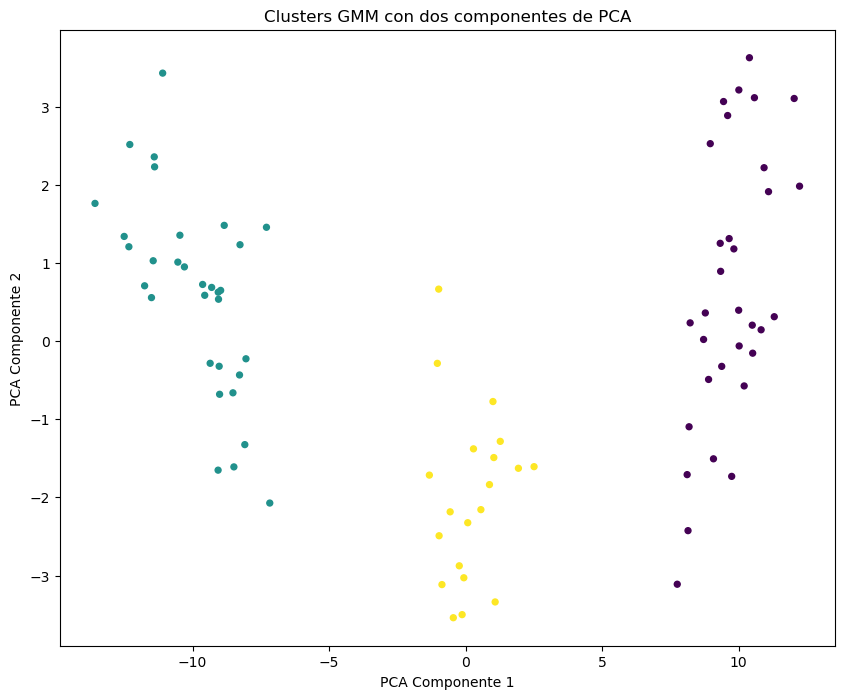

In [73]:


# Ploteamos los clusters

plt.figure(figsize=(10, 8))
plt.scatter(df_pca_shopping.values[:, 0], df_pca_shopping.values[:, 1], c= df_pca_shopping.values[:,2], cmap='viridis', s=18)

plt.xlabel('PCA Componente 1')
plt.ylabel('PCA Componente 2')
plt.title('Clusters GMM con dos componentes de PCA')
plt.show()


In [74]:
df.head()

,Bread,Milk,Eggs,Beer,Chips
Customer,,,,,
c001,12,10,8,0,1
c002,10,8,7,1,0
c003,11,9,6,0,1
c004,1,2,1,10,8
c005,0,1,2,12,10


In [75]:
df.describe()

,Bread,Milk,Eggs,Beer,Chips
count,84.000000,84.000000,84.000000,84.000000,84.000000
mean,6.297619,5.297619,4.142857,5.333333,4.630952
std,4.976523,3.731274,3.089597,4.616193,3.892470
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,1.000000,1.000000
50%,5.000000,5.000000,4.000000,4.000000,4.000000
75%,11.000000,9.000000,7.000000,10.000000,8.000000
max,15.000000,12.000000,10.000000,14.000000,12.000000


In [76]:
min_df = df.describe().iloc[3,:]
max_df = df.describe().iloc[-1,:]
min_df

Bread    0.0
Milk     0.0
Eggs     0.0
Beer     0.0
Chips    0.0
Name: min, dtype: float64

In [77]:
max_df

Bread    15.0
Milk     12.0
Eggs     10.0
Beer     14.0
Chips    12.0
Name: max, dtype: float64

In [78]:
# Cree un nuevo cliente con la misma estructura del dataframe original

import random

nuevo_dato = np.array([[random.randint(min_df.iloc[i], max_df.iloc[i]) for i in range(len(max_df))]])
nuevo_dato

array([[14,  0,  5, 11, 12]])

In [79]:
# Prediga el cluster al que pertenece este nuevo cliente
new_data_scale = scale.transform(nuevo_dato)
new_data_scale

c:\Users\x\.conda\envs\aaa_curso_2026\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 1.55703942, -1.42831569,  0.27909493,  1.23493561,  1.90452523]])

In [80]:
predict_cluster = gmm_shopping.predict(new_data_scale)
predict_cluster

c:\Users\x\.conda\envs\aaa_curso_2026\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [81]:
predict_proba_cluster = gmm_shopping.predict_proba(new_data_scale)
predict_proba_cluster

c:\Users\x\.conda\envs\aaa_curso_2026\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


array([[1.86062718e-28, 1.00000000e+00, 2.73244448e-11]])

**2.-**  Obtenga un modelo de clustering para el dataset `healthcare_dataset.csv` para obtener una agrupación de pacientes sanitarios mediante GMM: Los hospitales a menudo necesitan agrupar a pacientes con características similares para: identificar pacientes de alto riesgo, personalizar planes de tratamiento, optimizar la asignación de recursos y mejorar la gestión sanitaria.

In [1]:
# Realizamos la importación de utilerías por si no han sido importadas.

import os
os.environ["OMP_NUM_THREADS"] = "1"  

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [26]:
#Cargamos el dataset
df = pd.read_csv("C:/Users/x/OneDrive - MBGE INTERSISTEMAS/MBGE/DIT/IA/Maestria/Aprendizaje_Automatico_Avanzado_2026/Introducción/data/healthcare_dataset.csv")

# Cambiamos el tipo de dato de las columnas 'Date of Admission' y 'Discharge Date' a tipo datetime
# Creamos una nueva columna 'Length of Stay' que calcula la diferencia en días entre la fecha de alta y la fecha de ingreso.
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date']    = pd.to_datetime(df['Discharge Date'])
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20


In [27]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date,Length of Stay
count,55500.000000,55500,55500.000000,55500.000000,55500,55500.000000
mean,51.539459,2021-11-01 01:02:22.443243008,25539.316097,301.134829,2021-11-16 13:15:20.821621504,15.509009
min,13.000000,2019-05-08 00:00:00,-2008.492140,101.000000,2019-05-09 00:00:00,1.000000
25%,35.000000,2020-07-28 00:00:00,13241.224652,202.000000,2020-08-12 00:00:00,8.000000
50%,52.000000,2021-11-01 00:00:00,25538.069376,302.000000,2021-11-17 00:00:00,15.000000
75%,68.000000,2023-02-03 00:00:00,37820.508436,401.000000,2023-02-18 00:00:00,23.000000
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00,30.000000
std,19.602454,NaN,14211.454431,115.243069,NaN,8.659600


In [28]:
# Escalamiento y selección de características (¿Qué hacemos si tenemos columnas categoricas y numéricas y queremos utilizarlas en el clustering?)
# Separamos las columnas numéricas y categóricas. Las numéricas las escalamos y las categóricas se codifican con one-hot.
# Solo columnas categóricas que pueden codificrse con one-hot encoding, es decir, que no tengan demasiadas categorías.
from sklearn.preprocessing import StandardScaler

num_cols = ['Age', 'Billing Amount', 'Length of Stay']
cat_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']

scale = StandardScaler()
df_scale = pd.DataFrame(scale.fit_transform(df[num_cols]), columns=num_cols)
df_cat = pd.get_dummies(df[cat_cols], drop_first=True).astype(float)

# Info de los dataframes escalados y codificados
print('Para entrenar:', df_scale.shape, '| Para perfilar:', df_cat.shape)
df_scale.head()


Para entrenar: (55500, 3) | Para perfilar: (55500, 25)


,Age,Billing Amount,Length of Stay
0,-1.098824,-0.470261,-1.560018
1,0.533639,0.570250,-1.098099
2,1.247842,0.169990,-0.058780
3,-1.200853,0.870465,1.673417
4,-0.435636,-0.795211,0.518619


In [29]:
df_scale.describe()

,Age,Billing Amount,Length of Stay
count,5.550000e+04,5.550000e+04,5.550000e+04
mean,7.732753e-17,5.703546e-17,-4.852175e-17
std,1.000009e+00,1.000009e+00,1.000009e+00
min,-1.966071e+00,-1.938440e+00,-1.675498e+00
25%,-8.437519e-01,-8.653725e-01,-8.671390e-01
50%,2.349424e-02,-8.772730e-05,-5.878027e-02
75%,8.397259e-01,8.641834e-01,8.650582e-01
max,1.911030e+00,1.915723e+00,1.673417e+00


In [30]:
X = df_scale
X.shape

(55500, 3)

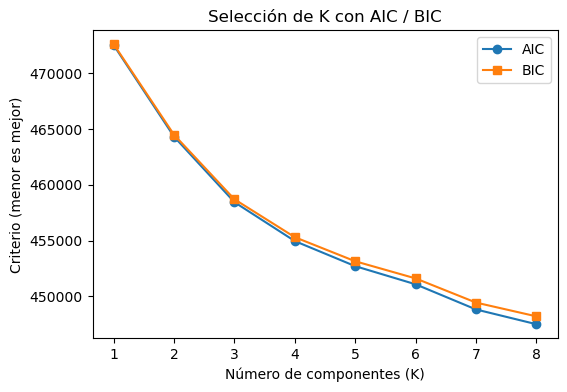

BIC mínimo en K = 8


In [31]:
from sklearn.mixture import GaussianMixture

ks = range(1, 9)
aics, bics = [], []
for k in ks:
    g = GaussianMixture(n_components=k, covariance_type='full', random_state=42).fit(X)
    aics.append(g.aic(X))
    bics.append(g.bic(X))

plt.figure(figsize=(6, 4))
plt.plot(ks, aics, 'o-', label='AIC')
plt.plot(ks, bics, 's-', label='BIC')
plt.xlabel('Número de componentes (K)')
plt.ylabel('Criterio (menor es mejor)')
plt.title('Selección de K con AIC / BIC')
plt.legend()
plt.show()

print('BIC mínimo en K =', list(ks)[int(np.argmin(bics))])

In [32]:
# Entrene el modelo por GMM utilice métricas para saber cuantos componentes elegir y cree una coluna para assignar el cluster
#gmm_healthcare = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
#gmm_healthcare.fit(X)

X_muestra = X.sample(6000, random_state=0)   
ks_sil = range(2, 8)
siluetas = []
for k in ks_sil:
    g = GaussianMixture(n_components=k, covariance_type='full', random_state=42).fit(X)
    siluetas.append(silhouette_score(X_muestra, g.predict(X_muestra)))
    print(f'K = {k}  ->  silueta = {siluetas[-1]:.4f}')

# Elegimos K=4: es un máximo local de la silueta y da 4 segmentos interpretables.
gmm_healthcare = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm_healthcare.fit(X)

K = 2  ->  silueta = 0.2427
K = 3  ->  silueta = 0.2391
K = 4  ->  silueta = 0.2612
K = 5  ->  silueta = 0.2506
K = 6  ->  silueta = 0.2822
K = 7  ->  silueta = 0.2754


,n_components,4
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [33]:
# asignación dura (cluster más probable)
predicciones = gmm_healthcare.predict(X)

# asignación suave (probabilidades de pertenencia)
responsabilidades = gmm_healthcare.predict_proba(X)

df['cluster'] = predicciones

print(f"Modelo entrenado con K = 4 componentes")
print(df.groupby('cluster')[num_cols].mean().round(1))

Modelo entrenado con K = 4 componentes
          Age  Billing Amount  Length of Stay
cluster                                      
0        69.3         13468.0            15.7
1        51.4         37701.7             7.7
2        51.6         37671.7            23.3
3        34.1         13234.4            15.3


In [34]:
# Aplicamos PCA para poder ver los datos en 2 dimensiones (n_components)
from sklearn.decomposition import PCA

pca_healthcare = PCA(n_components = 2)
X_pca_healthcare = pca_healthcare.fit_transform(X)
df_pca_healthcare = pd.DataFrame(X_pca_healthcare, columns = ['componente_1', 'componente_2'])

# Se agrega la columna de cluster al dataframe de PCA
df_pca_healthcare['gmm_cluster'] = predicciones
df_pca_healthcare.head()

# Cuánta información conserva la proyección 2D (antes era 34%, ahora 67%)
print('Varianza explicada por componente:', pca_healthcare.explained_variance_ratio_.round(3))
print('Total en 2 componentes:', round(pca_healthcare.explained_variance_ratio_.sum(), 3))

df_pca_healthcare

Varianza explicada por componente: [0.337 0.332]
Total en 2 componentes: 0.669


,componente_1,componente_2,gmm_cluster
0,-1.418632,-1.233337,3
1,-0.661856,0.547704,1
2,0.621704,0.756290,0
3,-0.072908,0.444590,2
4,0.460614,-0.795634,3
...,...,...,...
55495,1.565662,-1.299462,3
55496,-0.396016,0.455624,1
55497,0.437443,0.043929,2
55498,-1.197446,-0.007369,1


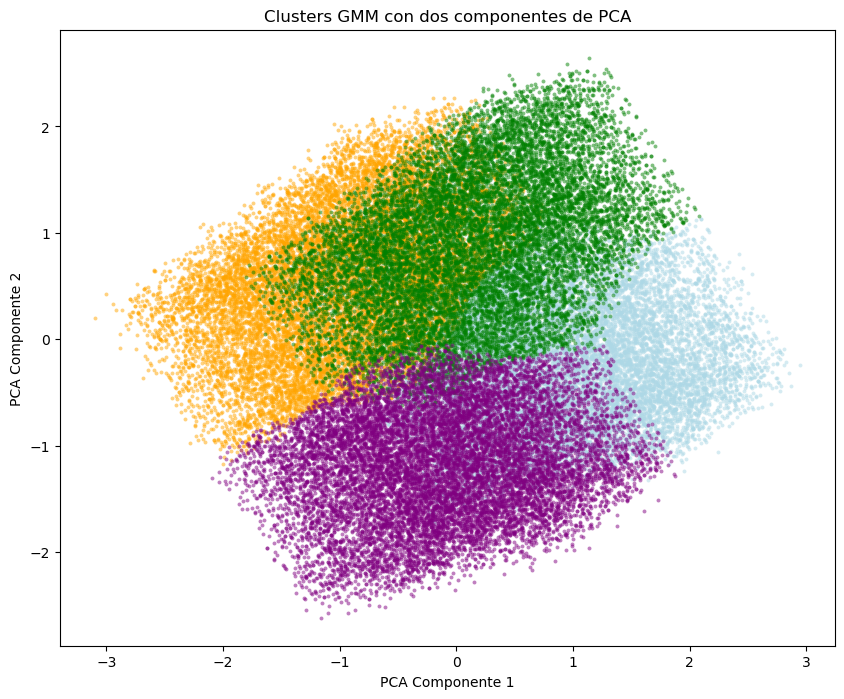

In [45]:
# Ploteamos los clusters
COLORES = ['lightblue', 'orange', 'green', 'purple']
GRIS_TXT = 'gray'

plt.figure(figsize=(10, 8))
#plt.scatter(df_pca_healthcare.values[:, 0], df_pca_healthcare.values[:, 1], c= df_pca_healthcare.values[:,2], cmap='viridis', s=18)

for k in range(4):
    s = df_pca_healthcare[df_pca_healthcare.gmm_cluster == k]
    plt.scatter(s.componente_1, s.componente_2, s=8, alpha=0.5,
                color = COLORES[k], linewidths=0, label=f'Cluster {k}')

plt.xlabel('PCA Componente 1')
plt.ylabel('PCA Componente 2')
plt.title('Clusters GMM con dos componentes de PCA')
plt.show()

In [36]:
# Cree un nuevo paciente con algunos valores en base a las columnas elegidas 

# 1: definimos al paciente con sus valores sin escalar 
nuevo_paciente = pd.DataFrame([{
    'Age': 72,
    'Billing Amount': 45000.0,
    'Length of Stay': 25
}])
nuevo_paciente

# Misma transformación que en el entrenamiento: transform, NO fit_transform
nuevo_paciente_scale = pd.DataFrame(scale.transform(nuevo_paciente[num_cols]),
                                    columns=num_cols)

predict_cluster = gmm_healthcare.predict(nuevo_paciente_scale)
predict_proba_cluster = gmm_healthcare.predict_proba(nuevo_paciente_scale)

print('Cluster asignado:', predict_cluster[0])
print('Probabilidades  :', predict_proba_cluster.round(4))

Cluster asignado: 2
Probabilidades  : [[0.0013 0.0014 0.9973 0.    ]]


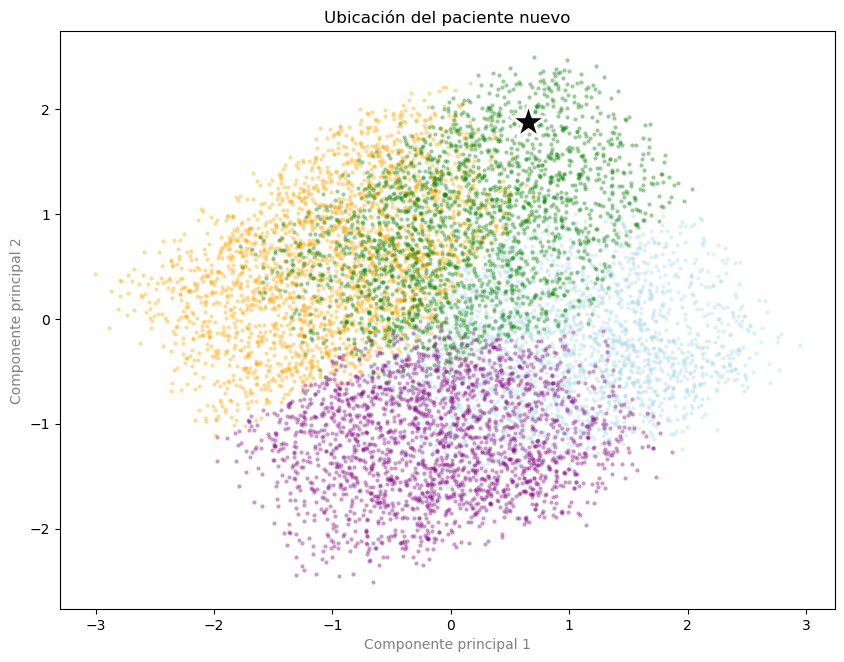

In [56]:
# Ubicación del paciente nuevo dentro de los clusters

k_asignado = predict_cluster[0]
p_asignada = predict_proba_cluster[0][k_asignado]

# Proyectamos al paciente al espacio PCA
nuevo_pca = pca_healthcare.transform(nuevo_paciente_scale)

m = df_pca_healthcare.sample(9000, random_state=0)

fig, ax = plt.subplots(figsize=(10, 7.5))
for k in range(4):
    s = m[m.gmm_cluster == k]
    ax.scatter(s.componente_1, s.componente_2, s=9, alpha=0.40,
               color=COLORES[k], linewidths=0, label=f'Cluster {k}')

ax.scatter(nuevo_pca[0, 0], nuevo_pca[0, 1], marker='*', s=700,
           color='#0b0b0b', edgecolors='#fcfcfb', linewidths=2, zorder=6)

ax.set_xlabel('Componente principal 1', color=GRIS_TXT)
ax.set_ylabel('Componente principal 2', color=GRIS_TXT)
ax.set_title(f'Ubicación del paciente nuevo')

plt.show()

